# Electrical Breakdown Data Analysis

This notebook provides a comprehensive analysis of electrical breakdown data. The study includes data cleaning, exploratory data analysis (EDA), and visualizations of various breakdown metrics across divisions and circles.

### Key Objectives:
1. Analyze breakdown frequency by Division and Voltage.
2. Evaluate response time (Duration) and closure performance.
3. Identify common fault locations and relay reasons.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set consistent visualization theme
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
palette = sns.color_palette("viridis")

## Helper Functions for Visualization
To maintain consistency and reduce code duplication, we'll define a utility for plotting annotated bar charts.

In [58]:
def plot_annotated_bar(data, x, y, title, palette='viridis'):
    plt.figure(figsize=(12, 6))
    # Use palette for colormaps like 'viridis', 'magma', etc.
    ax = sns.barplot(x=x, y=y, data=data, palette=palette, hue=x, legend=False)
    
    plt.title(title, fontsize=15, pad=20)
    plt.xticks(rotation=45)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=3)
    
    # Add Max/Min annotations
    max_val = data[y].max()
    min_val = data[y].min()
    max_label = data[data[y] == max_val][x].values[0]
    min_label = data[data[y] == min_val][x].values[0]
    
    stats_text = f'Max: {max_val} ({max_label})\nMin: {min_val} ({min_label})'
    plt.gca().text(0.98, 0.95, stats_text, ha='right', va='top', 
                   transform=plt.gca().transAxes, fontsize=10, 
                   bbox=dict(facecolor='white', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

In [59]:
df = pd.read_excel('BDData.xls')

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


## Enhanced Data Cleaning & Feature Engineering
Converting date objects and extracting temporal features for deeper analysis.

## Breakdown Duration and Closure Performance


In [60]:
# Convert to datetime and calculate duration if not already done
df['INSERTEDDATE'] = pd.to_datetime(df['INSERTEDDATE'])
df['CLOSINGDATE'] = pd.to_datetime(df['CLOSINGDATE'])
df['Duration'] = (df['CLOSINGDATE'] - df['INSERTEDDATE']).dt.total_seconds() / 3600

# Extract temporal features
df['Month'] = df['INSERTEDDATE'].dt.month_name()
df['DayOfWeek'] = df['INSERTEDDATE'].dt.day_name()
df['Hour'] = df['INSERTEDDATE'].dt.hour

# Handle negative durations if any
negative_durations = df[df['Duration'] < 0].shape[0]
if negative_durations > 0:
    print(f'Found {negative_durations} negative durations. Setting them to 0.')
    df.loc[df['Duration'] < 0, 'Duration'] = 0

print('New features added: Month, DayOfWeek, Hour')
df.head()

New features added: Month, DayOfWeek, Hour


,BD_ID,FAULT_ID,SAP_NOTIFICATION_NO,STATUS,DIVISION,GRID_ID,FEEDER_ID,SUBSTATION_ID,DT_ID,VOLTAGE,...,LTFEEDER_NAME,GRID_FL,DT_SAPID,FROM_SUBSTATION,TO_SUBSTATION,CLIENT_IP,Duration,Month,DayOfWeek,Hour
0,B09042400014,NNG09042400029,501425973.0,2,NNG,DLDLHIDGNR6002,NAND-11KV-009262,NaN,NaN,HT,...,NaN,NaN,NaN,NaN,NaN,NaN,31.378056,April,Tuesday,14
1,B06012400001,KRN06012400021,NaN,2,KRN,DLDLHIKRNR3002,GEET-11KV-008681,"DLDLHIKRNF100A,","DLDLHIKRNF100AXXXXDT0001,",LT,...,NaN,NaN,NaN,NaN,NaN,NaN,0.429722,January,Saturday,10
2,B08012400017,MVR08012400079,501397611.0,2,MVR,DLDLHIMVRR6002,MAY2-11KV-009170,"DLDLHIMVR34825,","DLDLHIMVR34825XXXXDT0002,",LT,...,NaN,NaN,NaN,NaN,NaN,NaN,55.251944,January,Monday,14
3,B10012400019,CCK10012400037,501398528.0,2,CCK,DLDLHICCKR0001,2KAG-11KV-121099,NaN,NaN,HT,...,NaN,NaN,NaN,NaN,NaN,NaN,31.412222,January,Wednesday,15
4,B23012400006,VSE23012400009,NaN,2,VSE,DLDLHIVSER6002,KOND-11KV-009091,"DLDLHIVSES104T,","DLDLHIVSES104TXXXXDT0001,",LT,...,NaN,NaN,NaN,NaN,NaN,NaN,0.549167,January,Tuesday,10


## Summary Statistics
Quick overview of the numerical and categorical distributions.

## Fault Location and Relay Reason Analysis


In [61]:
print('--- Numerical Summary ---')
display(df[['Duration', 'Hour']].describe())

print('\n--- Top 5 Fault Locations ---')
print(df['FAULTLOCATION'].value_counts().head())

print('\n--- Top 5 Relay Reasons ---')
print(df['RELAY_REASON'].value_counts().head())

--- Numerical Summary ---


,Duration,Hour
count,3527.000000,3620.000000
mean,36.627297,12.223204
std,263.997783,5.636391
min,0.008333,0.000000
25%,0.554722,9.000000
50%,1.113333,13.000000
75%,20.852917,16.000000
max,9584.532778,23.000000



--- Top 5 Fault Locations ---
FAULTLOCATION
FEEDER        2320
LTFEEDER      1157
SUBSTATION      72
DT              71
Name: count, dtype: int64

--- Top 5 Relay Reasons ---
RELAY_REASON
TRIPPING          3004
LOAD REDUCED       348
LOAD DISAPPEAR     214
Name: count, dtype: int64


## Temporal Trends Analysis
Visualizing how breakdowns are distributed across days of the week and hours of the day.

C:\Users\HP\AppData\Local\Temp\ipykernel_24352\332422046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DayOfWeek', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='magma')


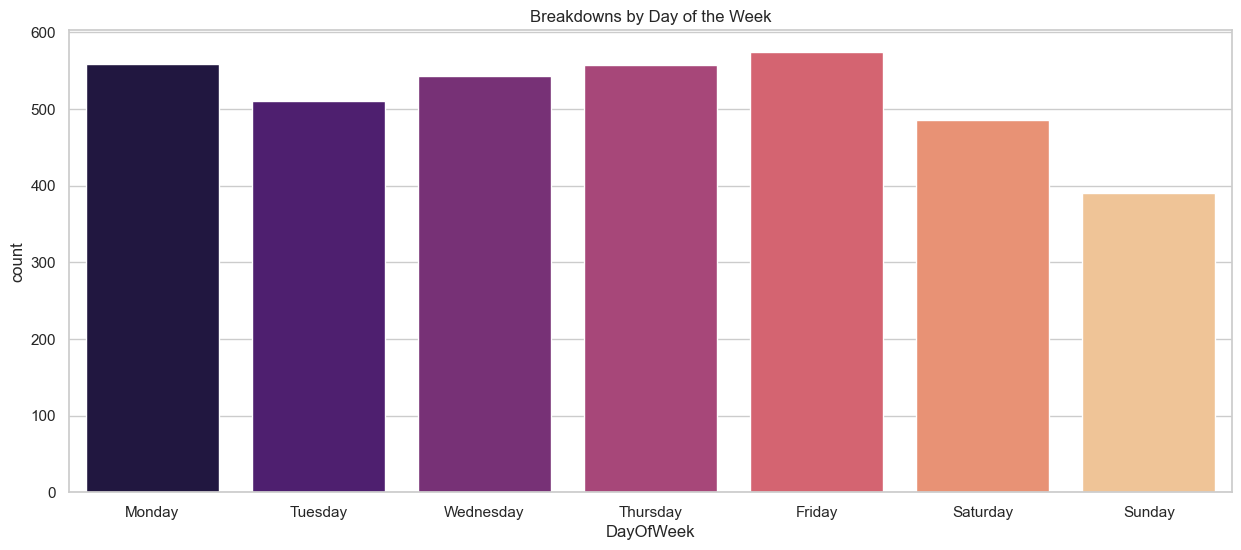

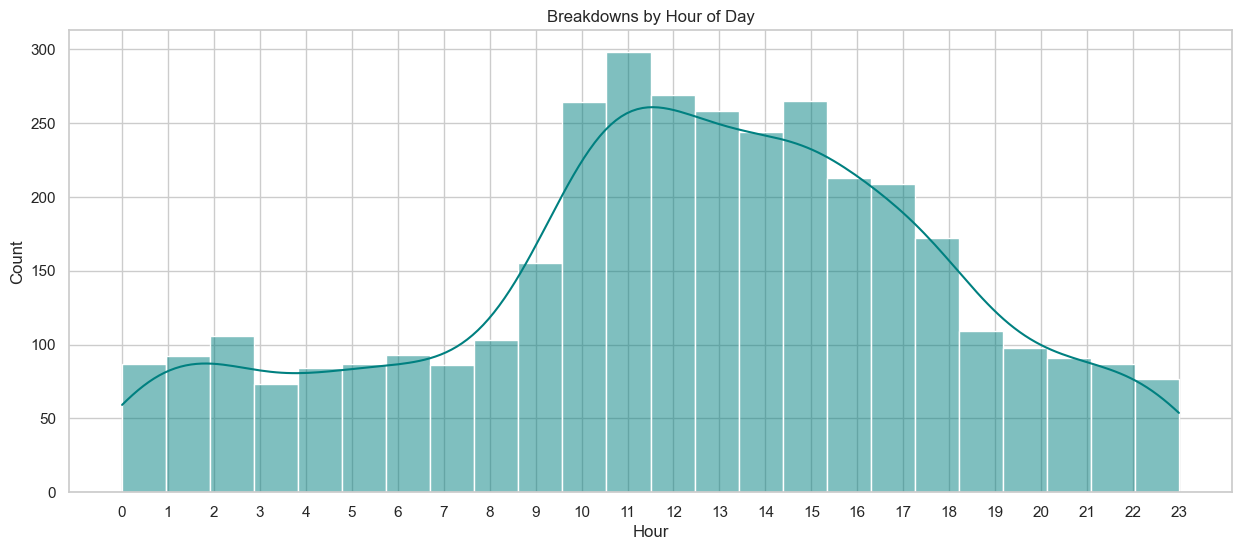

In [62]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='DayOfWeek', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='magma')
plt.title('Breakdowns by Day of the Week')
plt.show()

plt.figure(figsize=(15, 6))
sns.histplot(data=df, x='Hour', bins=24, kde=True, color='teal')
plt.title('Breakdowns by Hour of Day')
plt.xticks(range(0, 24))
plt.show()

In [63]:
df.head()

,BD_ID,FAULT_ID,SAP_NOTIFICATION_NO,STATUS,DIVISION,GRID_ID,FEEDER_ID,SUBSTATION_ID,DT_ID,VOLTAGE,...,LTFEEDER_NAME,GRID_FL,DT_SAPID,FROM_SUBSTATION,TO_SUBSTATION,CLIENT_IP,Duration,Month,DayOfWeek,Hour
0,B09042400014,NNG09042400029,501425973.0,2,NNG,DLDLHIDGNR6002,NAND-11KV-009262,NaN,NaN,HT,...,NaN,NaN,NaN,NaN,NaN,NaN,31.378056,April,Tuesday,14
1,B06012400001,KRN06012400021,NaN,2,KRN,DLDLHIKRNR3002,GEET-11KV-008681,"DLDLHIKRNF100A,","DLDLHIKRNF100AXXXXDT0001,",LT,...,NaN,NaN,NaN,NaN,NaN,NaN,0.429722,January,Saturday,10
2,B08012400017,MVR08012400079,501397611.0,2,MVR,DLDLHIMVRR6002,MAY2-11KV-009170,"DLDLHIMVR34825,","DLDLHIMVR34825XXXXDT0002,",LT,...,NaN,NaN,NaN,NaN,NaN,NaN,55.251944,January,Monday,14
3,B10012400019,CCK10012400037,501398528.0,2,CCK,DLDLHICCKR0001,2KAG-11KV-121099,NaN,NaN,HT,...,NaN,NaN,NaN,NaN,NaN,NaN,31.412222,January,Wednesday,15
4,B23012400006,VSE23012400009,NaN,2,VSE,DLDLHIVSER6002,KOND-11KV-009091,"DLDLHIVSES104T,","DLDLHIVSES104TXXXXDT0001,",LT,...,NaN,NaN,NaN,NaN,NaN,NaN,0.549167,January,Tuesday,10


In [64]:
len(df)

3620

In [65]:
df.isnull().sum()

BD_ID                     0
FAULT_ID                  0
SAP_NOTIFICATION_NO    2094
STATUS                    0
DIVISION                  0
                       ... 
CLIENT_IP              3620
Duration                 93
Month                     0
DayOfWeek                 0
Hour                      0
Length: 128, dtype: int64

In [123]:
missing = df.isnull().sum().reset_index()
missing.columns = ['column', 'num_missing']
missing.to_csv('missing_counts.csv', index=False)
df.to_csv('BDData.csv', index = False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3620 entries, 0 to 3619
Columns: 128 entries, BD_ID to Hour
dtypes: datetime64[ns](12), float64(29), int32(1), int64(14), object(72)
memory usage: 3.5+ MB


In [68]:
from collections import Counter

## Division and Circle Analysis


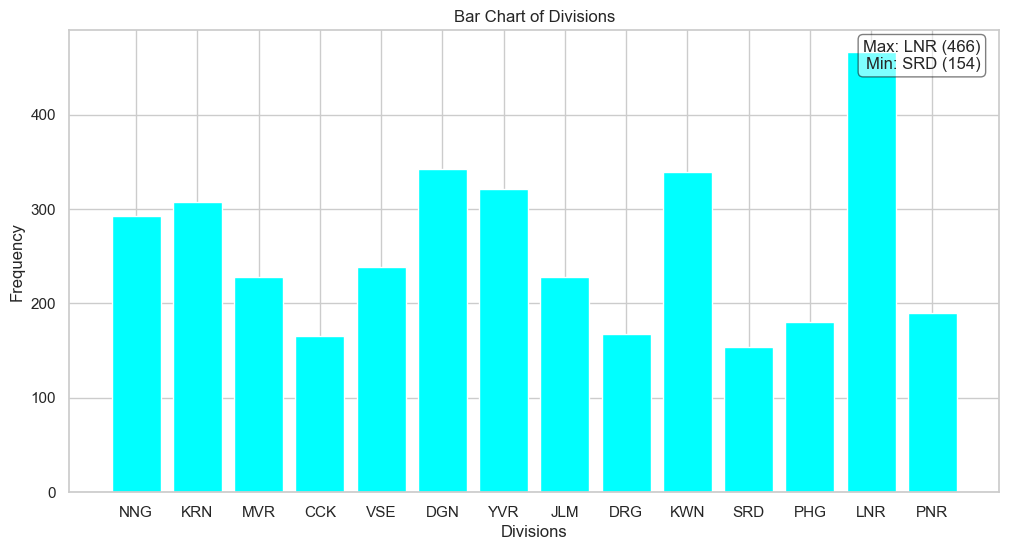

In [69]:
counts = Counter(df['DIVISION'])
plt.bar(counts.keys(), counts.values(), color= 'cyan')
plt.title("Bar Chart of Divisions")
plt.xlabel("Divisions")
plt.ylabel("Frequency")

max_div = max(counts, key=counts.get)
max_val = counts[max_div]
min_div = min(counts, key=counts.get)
min_val = counts[min_div]

info_text = f"Max: {max_div} ({max_val})\nMin: {min_div} ({min_val})"

plt.gca().text(
    0.98, 0.98,
    info_text,
    ha='right',
    va='top',
    transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.5)
)

plt.show()

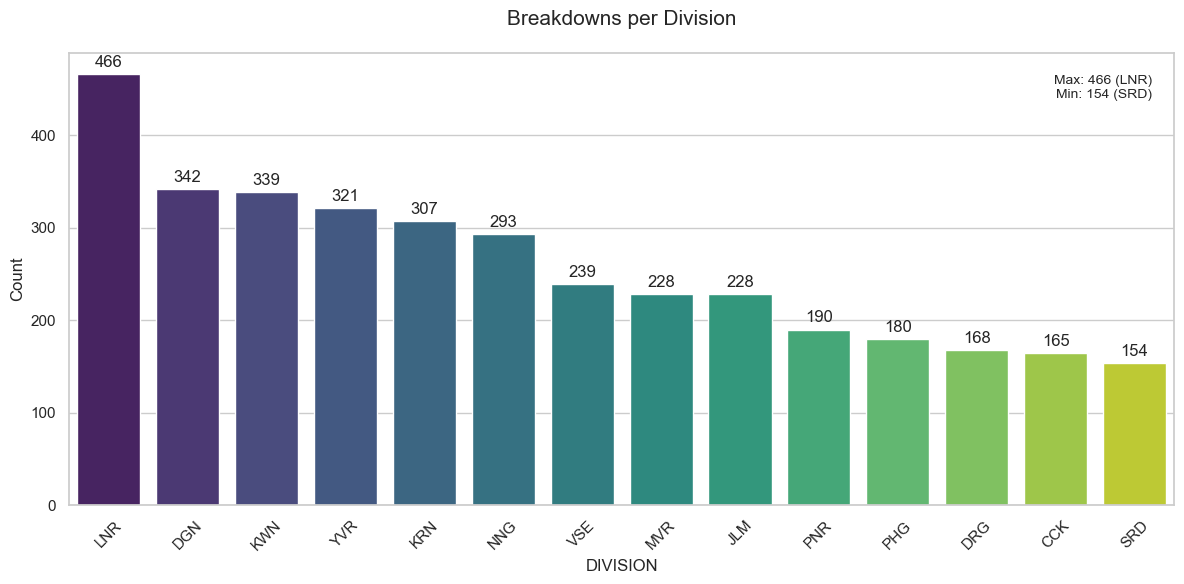

In [70]:
division_counts = df['DIVISION'].value_counts().reset_index()
division_counts.columns = ['DIVISION', 'Count']
plot_annotated_bar(division_counts, 'DIVISION', 'Count', 'Breakdowns per Division')

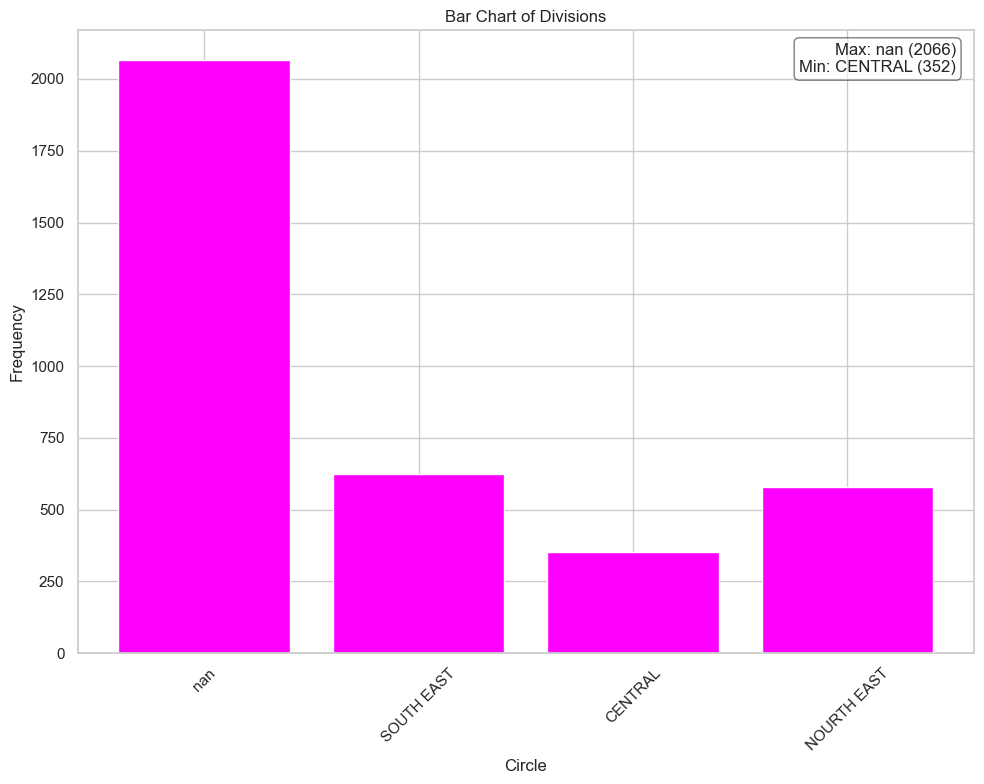

In [71]:
counts2 = Counter(df['CIRCLE'].astype(str))

plt.figure(figsize=(10,8))
plt.bar(counts2.keys(), counts2.values(), color='magenta')
plt.title("Bar Chart of Divisions")
plt.xlabel("Circle")
plt.ylabel("Frequency")

max_div = max(counts2, key=counts2.get)
max_val = counts2[max_div]
min_div = min(counts2, key=counts2.get)
min_val = counts2[min_div]

info_text = f"Max: {max_div} ({max_val})\nMin: {min_div} ({min_val})"

plt.gca().text(
    0.98, 0.98,
    info_text,
    ha='right',
    va='top',
    transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.5)
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
print(df['SUBDIVISION_NAME'])
print(df['SUBDIVISION_NAME'].value_counts())
counts

0                         NaN
1                 KANTI NAGAR
2                 TRILOK PURI
3               HAMILTON ROAD
4       MAYUR VIHAR PHASE-III
                ...          
3615                      NaN
3616                      NaN
3617                      NaN
3618                      NaN
3619                      NaN
Name: SUBDIVISION_NAME, Length: 3620, dtype: object
SUBDIVISION_NAME
E&F DILSHAD GARDEN            86
C-12 YAMUNA VIHAR             82
SONIA VIHAR                   69
LAXMI NAGAR                   66
C-4 NANDNAGRI                 61
MANDAWALI                     59
SADAR APPARTMENTS             55
MIG EAST OF LONI ROAD         52
CHUNA MANDI & RAM NAGAR       52
ANAND VIHAR ISBT              49
SHASTRI PARK                  39
MAYUR VIHAR PHASE-III         37
CHHAPARWALAN                  36
SAINI ENCLAVE                 35
KANTI NAGAR                   34
PATEL NAGAR                   33
S/STN 8 POCKET CNO 2          33
JWALA NAGAR                   33
JAMA MA

Counter({'LNR': 466,
         'DGN': 342,
         'KWN': 339,
         'YVR': 321,
         'KRN': 307,
         'NNG': 293,
         'VSE': 239,
         'MVR': 228,
         'JLM': 228,
         'PNR': 190,
         'PHG': 180,
         'DRG': 168,
         'CCK': 165,
         'SRD': 154})

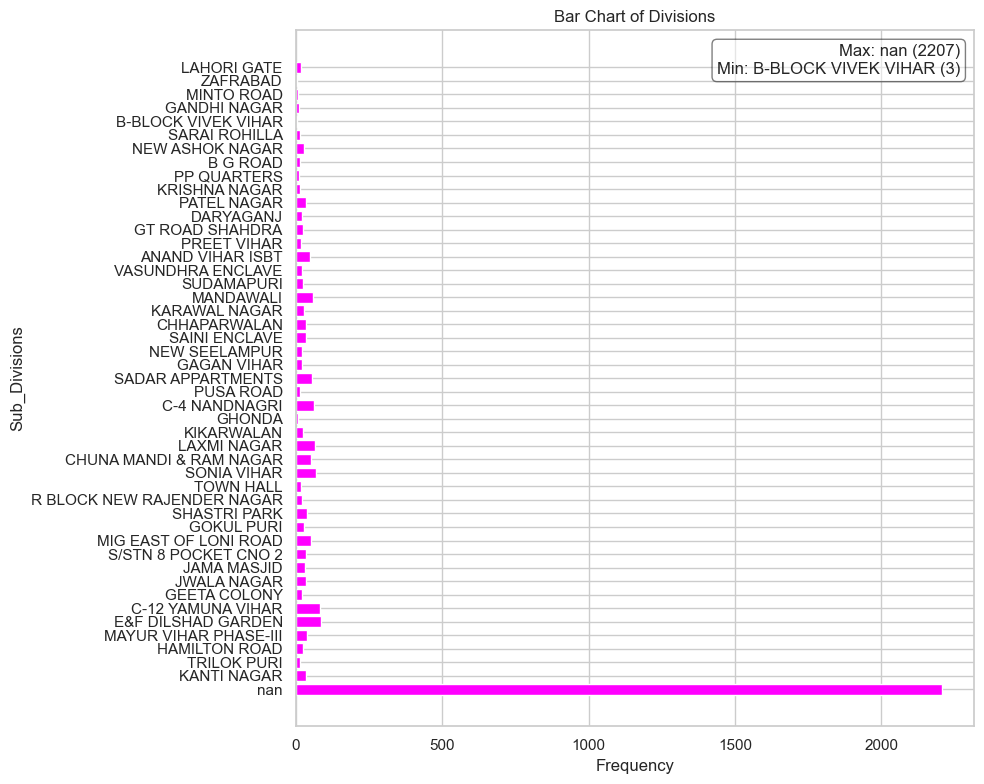

In [73]:
counts3 = Counter(df['SUBDIVISION_NAME'].astype(str))
plt.figure(figsize=(10,8))
plt.barh(counts3.keys(), counts3.values(), color='magenta')
plt.title("Bar Chart of Divisions")
plt.xlabel("Frequency")
plt.ylabel("Sub_Divisions")

max_div = max(counts3, key=counts3.get)
max_val = counts3[max_div]
min_div = min(counts3, key=counts3.get)
min_val = counts3[min_div]

info_text = f"Max: {max_div} ({max_val})\nMin: {min_div} ({min_val})"

plt.gca().text(
    0.98, 0.98,
    info_text,
    ha='right',
    va='top',
    transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.5)
)
plt.tight_layout()
plt.show()

In [74]:
df.groupby(['CIRCLE', 'DIVISION', 'SUBDIVISION'])['VOLTAGE'].unique()


CIRCLE       DIVISION  SUBDIVISION
CENTRAL      CCK       HLTX               [HT]
                       JMDX           [HT, LT]
                       LHRX           [HT, LT]
                       TWHX           [LT, HT]
             DRG       DRGX           [HT, LT]
                       JMDX           [HT, LT]
                       RQMX           [LT, HT]
             PHG       BGDX           [HT, LT]
                       CHMX           [HT, LT]
                       PPQX           [HT, LT]
             PNR       EPNX           [HT, LT]
                       KKRX           [HT, LT]
                       SRLX           [HT, LT]
             SRD       CPWX           [HT, LT]
                       PUSX           [HT, LT]
                       SRDX           [HT, LT]
NOURTH EAST  DGN       GTRX           [HT, LT]
                       NSMX           [LT, HT]
                       SLPX           [HT, LT]
                       WJNX           [HT, LT]
                       ZF

In [75]:
subdivision_per_division = df.groupby(['CIRCLE', 'DIVISION'])['SUBDIVISION'].nunique().reset_index(name='SubDiv_Count')
subdivision_per_division

,CIRCLE,DIVISION,SubDiv_Count
0,CENTRAL,CCK,4
1,CENTRAL,DRG,3
2,CENTRAL,PHG,3
3,CENTRAL,PNR,3
4,CENTRAL,SRD,3
5,NOURTH EAST,DGN,5
6,NOURTH EAST,KWN,5
7,NOURTH EAST,NNG,3
8,NOURTH EAST,YVR,4
9,SOUTH EAST,JLM,4


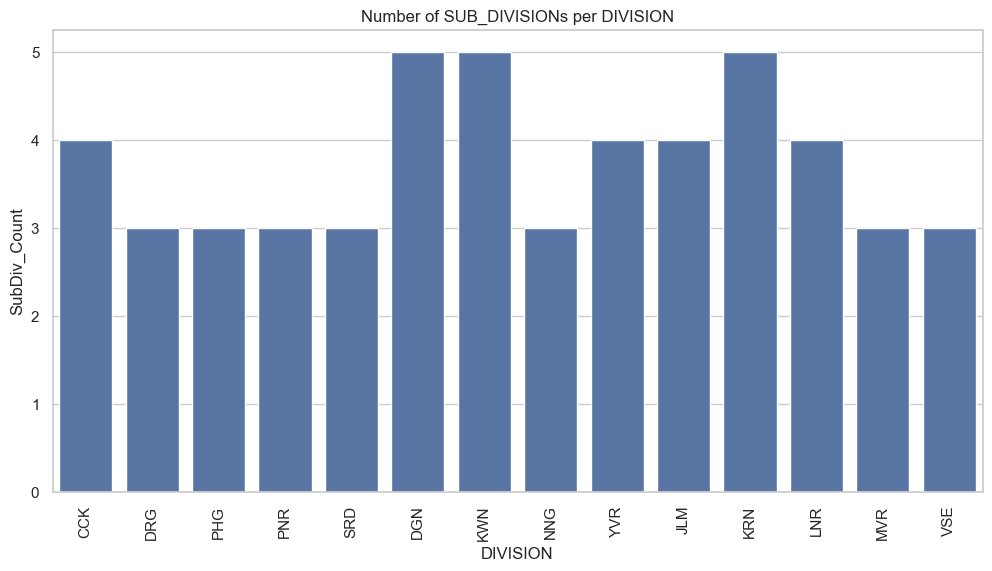

In [76]:
plt.figure(figsize=(12, 6))
sns.barplot(x='DIVISION', y='SubDiv_Count', data=subdivision_per_division)
plt.xticks(rotation=90)
plt.title("Number of SUB_DIVISIONs per DIVISION")
plt.show()

In [77]:
division_per_circle = df.groupby(['CIRCLE'])['DIVISION'].nunique().reset_index(name='Div_Count')
division_per_circle

,CIRCLE,Div_Count
0,CENTRAL,5
1,NOURTH EAST,4
2,SOUTH EAST,5


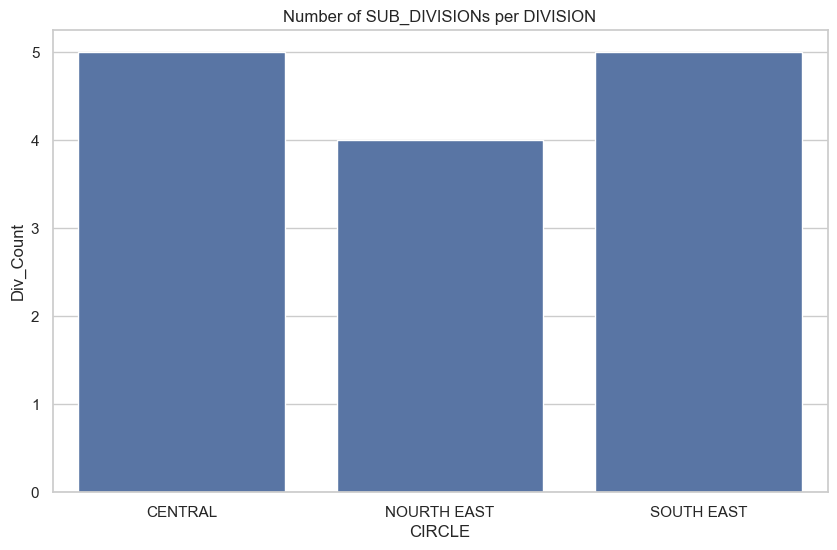

In [78]:
plt.figure(figsize=(10, 6))
sns.barplot(x='CIRCLE', y='Div_Count', data=division_per_circle)
plt.title("Number of SUB_DIVISIONs per DIVISION")
plt.show()

In [79]:
SUBdivision_per_circle = df.groupby(['CIRCLE'])['SUBDIVISION'].nunique().reset_index(name='SubDiv_Count')
SUBdivision_per_circle

,CIRCLE,SubDiv_Count
0,CENTRAL,15
1,NOURTH EAST,13
2,SOUTH EAST,19


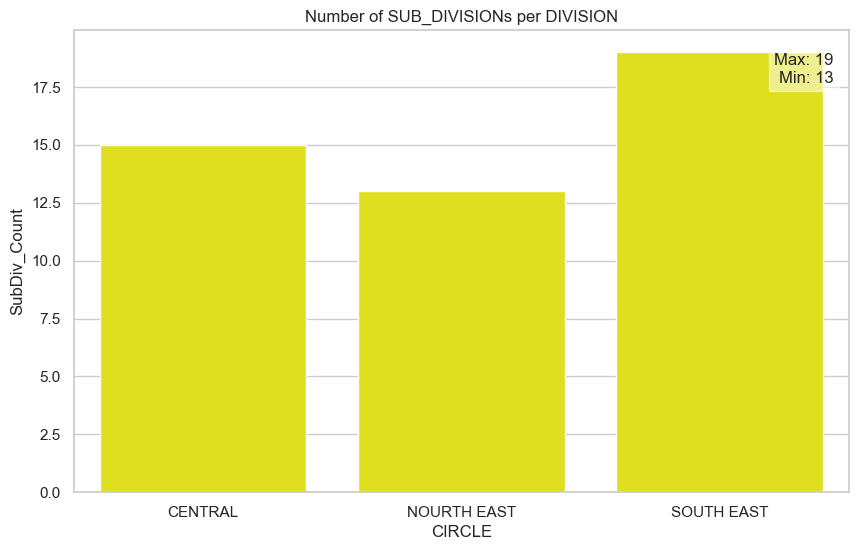

In [80]:
plt.figure(figsize=(10, 6))
sns.barplot(x='CIRCLE', y='SubDiv_Count', data=SUBdivision_per_circle,color = 'yellow')
plt.title("Number of SUB_DIVISIONs per DIVISION")

max_val = SUBdivision_per_circle['SubDiv_Count'].max()
min_val = SUBdivision_per_circle['SubDiv_Count'].min()

annotation_text = f'Max: {max_val}\nMin: {min_val}'

plt.gca().text(0.98, 0.95, annotation_text, ha='right', va='top',
               transform=plt.gca().transAxes, fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))

plt.show()


## Voltage Analysis (HT vs LT)


In [81]:
total_counts = df['VOLTAGE'].value_counts().reindex(['HT', 'LT'], fill_value=0)
total_counts

VOLTAGE
HT    2463
LT    1157
Name: count, dtype: int64

In [82]:
result = df.groupby(['DIVISION', 'VOLTAGE']).size().unstack(fill_value=0)[['HT', 'LT']]
result

VOLTAGE,HT,LT
DIVISION,,
CCK,113,52
DGN,200,142
DRG,138,30
JLM,155,73
KRN,202,105
KWN,275,64
LNR,302,164
MVR,141,87
NNG,218,75


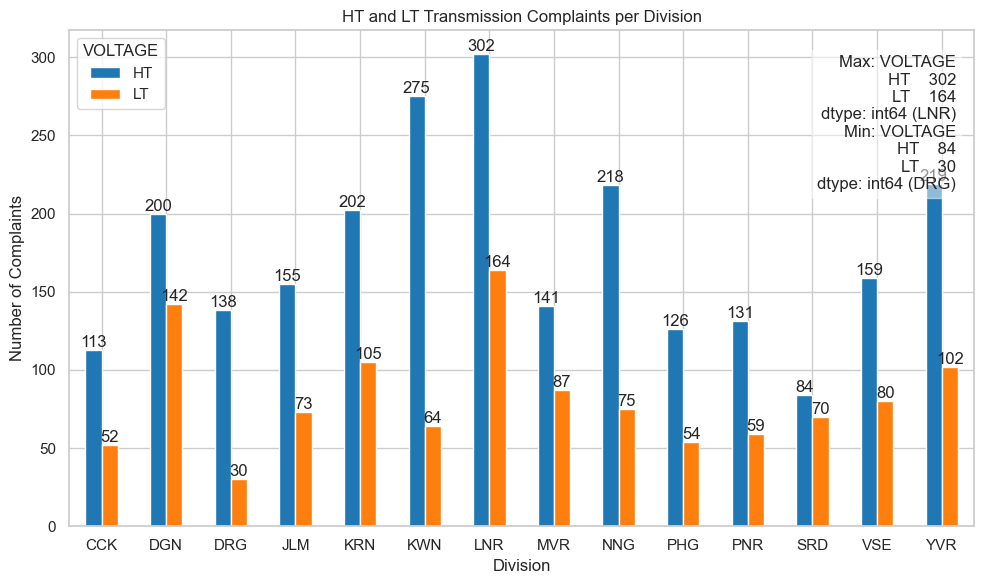

In [83]:
yx=result.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('HT and LT Transmission Complaints per Division')
plt.xlabel('Division')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=0)
plt.tight_layout()
for container in yx.containers:
    yx.bar_label(container, label_type='edge')
max_count = result.max()
min_count = result.min()
max_division = result[result == max_count].stack().index[0][0]
min_division = result[result == min_count].stack().index[0][0]
annotation = (f'Max: {max_count} ({max_division})\n'
              f'Min: {min_count} ({min_division})')

plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))
plt.show()

In [84]:
result = total_counts.sum()
print("Overall total voltage complaints (HT + LT):", result)

Overall total voltage complaints (HT + LT): 3620


(array([0, 1]), [Text(0, 0, 'HT'), Text(1, 0, 'LT')])

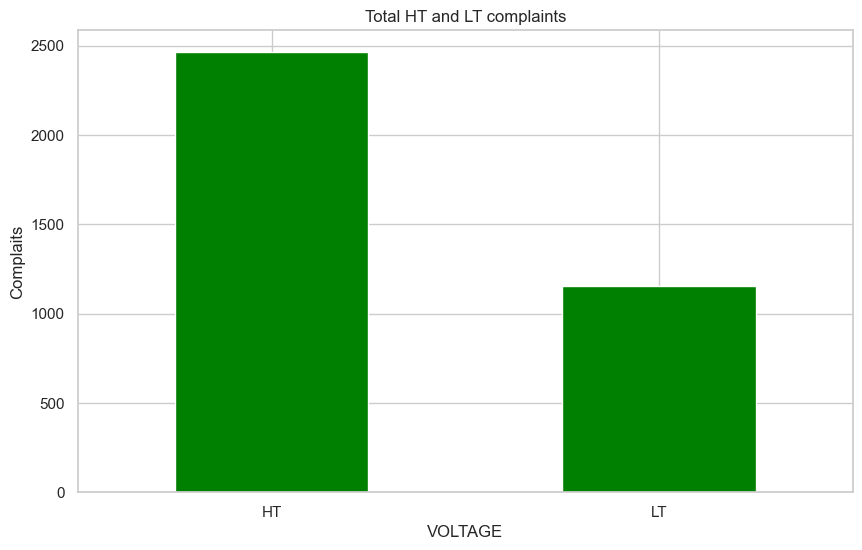

In [85]:
total_counts.plot(kind='bar',figsize=(10,6),color ='green')
plt.title('Total HT and LT complaints')
plt.ylabel('Complaits')
plt.xticks(rotation=0)

In [86]:
result = df.groupby(['DIVISION', 'VOLTAGE']).size().unstack(fill_value=0)[['HT']]
result

VOLTAGE,HT
DIVISION,
CCK,113
DGN,200
DRG,138
JLM,155
KRN,202
KWN,275
LNR,302
MVR,141
NNG,218


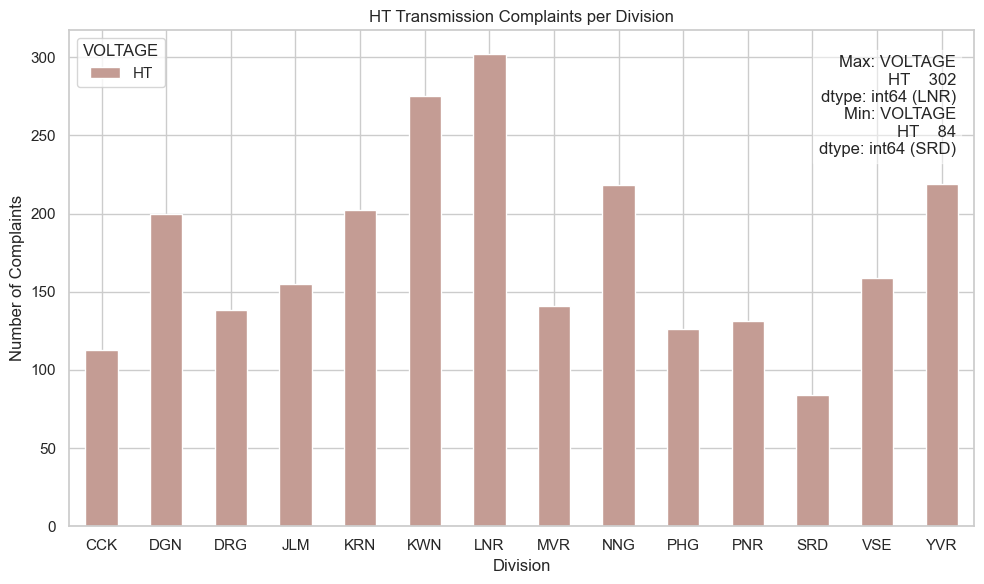

In [87]:
result.plot(kind='bar', figsize=(10, 6), color=['#c49c94',])
plt.title('HT Transmission Complaints per Division')
plt.xlabel('Division')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=0)
plt.tight_layout()
max_count = result.max()
min_count = result.min()
max_division = result[result == max_count].stack().index[0][0]
min_division = result[result == min_count].stack().index[0][0]
annotation = (f'Max: {max_count} ({max_division})\n'
              f'Min: {min_count} ({min_division})')

plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))
plt.show()

## Breakdown Type Analysis


In [88]:
breakdown_counts = df['BREAKDOWN_TYPE'].value_counts()
print(breakdown_counts)

BREAKDOWN_TYPE
BREAKDOWN         1860
FAULTY CABLE      1530
YTA                126
BD MAINTENANCE     104
Name: count, dtype: int64


In [89]:
breakdown_table = breakdown_counts.reset_index()
breakdown_table.columns = ['BREAKDOWN_TYPE', 'COUNT']
print(breakdown_table)

   BREAKDOWN_TYPE  COUNT
0       BREAKDOWN   1860
1    FAULTY CABLE   1530
2             YTA    126
3  BD MAINTENANCE    104


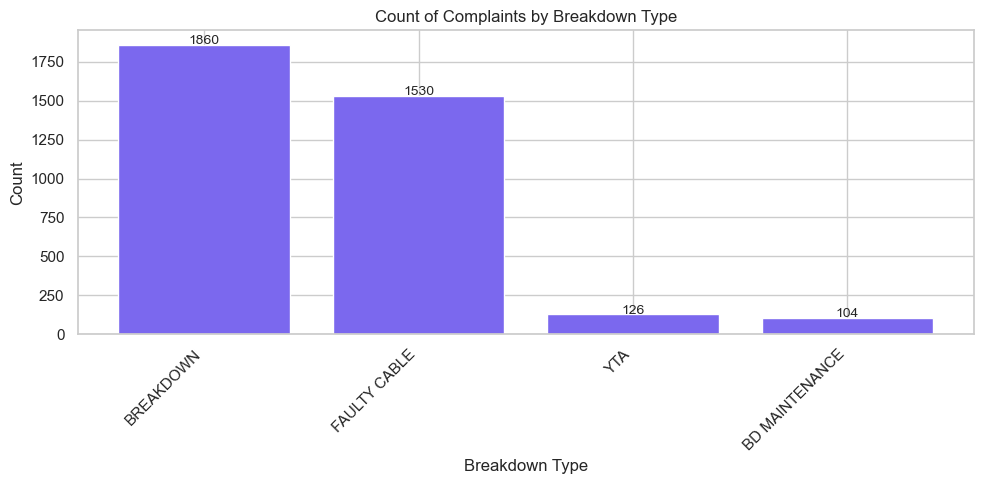

In [90]:
plt.figure(figsize=(10, 5))
bars = plt.bar(breakdown_table['BREAKDOWN_TYPE'], breakdown_table['COUNT'], color='mediumslateblue')
plt.xlabel('Breakdown Type')
plt.ylabel('Count')
plt.title('Count of Complaints by Breakdown Type')
for index, value in enumerate(breakdown_counts.values):
    plt.text(index, value + 5, str(value), ha='center', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [91]:
total_counts = df['BREAKDOWN_TYPE'].value_counts().reindex(['FAULTY CABLE', 'BREAKDOWN','BD MAINTENANCE','YTA'], fill_value=0)
total_counts

BREAKDOWN_TYPE
FAULTY CABLE      1530
BREAKDOWN         1860
BD MAINTENANCE     104
YTA                126
Name: count, dtype: int64

Text(0.98, 0.95, 'Max: 1860 (BREAKDOWN)\nMin: 104 (BD MAINTENANCE)')

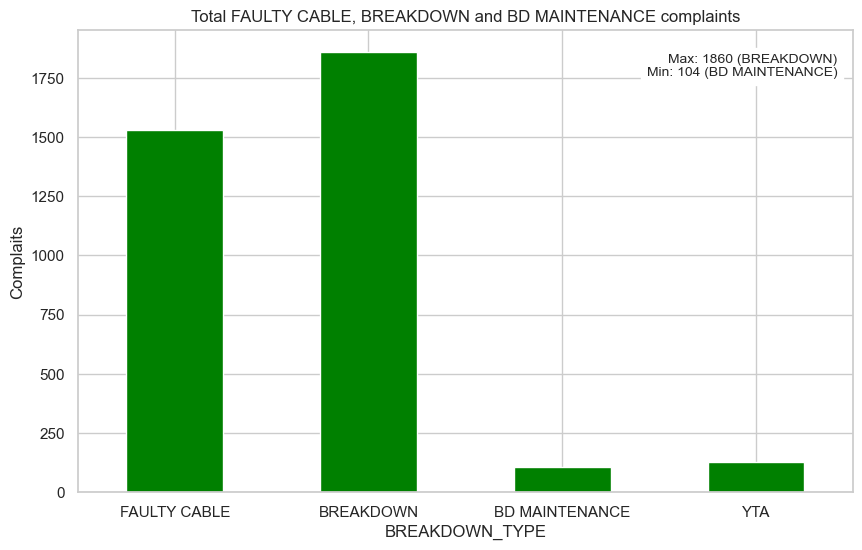

In [92]:
total_counts.plot(kind='bar',figsize=(10,6),color ='green')
plt.title('Total FAULTY CABLE, BREAKDOWN and BD MAINTENANCE complaints')
plt.ylabel('Complaits')
plt.xticks(rotation=0)
max_count= total_counts.max()
min_count = total_counts.min()
max_category = total_counts.idxmax()
min_category = total_counts.idxmin()
annotation = f"Max: {max_count} ({max_category})\nMin: {min_count} ({min_category})"
plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=10,
               bbox=dict(facecolor='white'))

In [93]:
result = df.groupby(['DIVISION', 'BREAKDOWN_TYPE']).size().unstack(fill_value=0)[['FAULTY CABLE', 'BREAKDOWN','BD MAINTENANCE','YTA']]
result

BREAKDOWN_TYPE,FAULTY CABLE,BREAKDOWN,BD MAINTENANCE,YTA
DIVISION,,,,
CCK,58,101,4,2
DGN,148,187,7,0
DRG,78,88,2,0
JLM,93,109,2,24
KRN,117,134,26,30
KWN,140,192,6,1
LNR,192,226,12,36
MVR,98,115,2,13
NNG,129,157,7,0


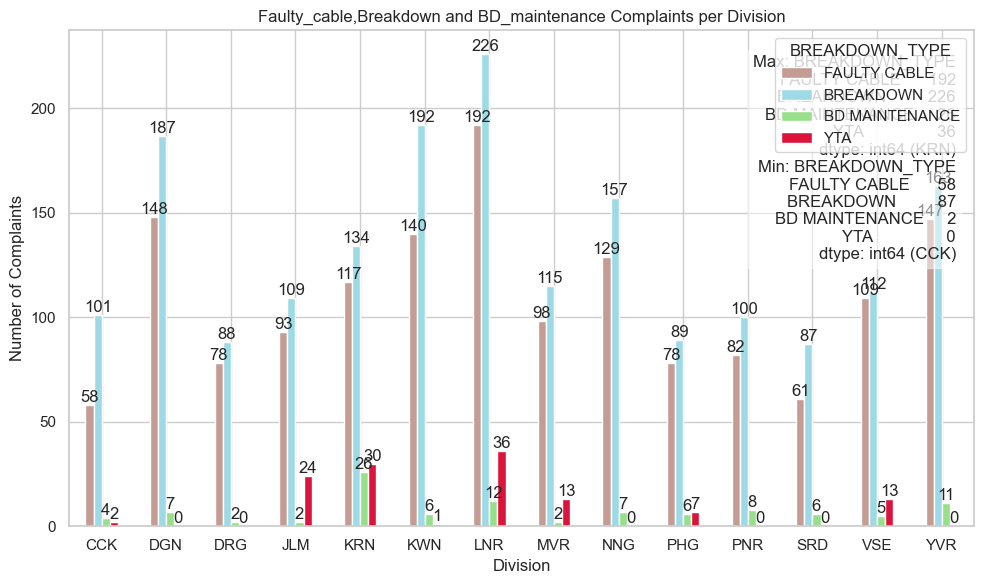

In [94]:
ax=result.plot(kind='bar', figsize=(10, 6), color=['#c49c94','#9edae5','#98df8a','crimson'])
plt.title('Faulty_cable,Breakdown and BD_maintenance Complaints per Division')
plt.xlabel('Division')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=0)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
max_count = result.max()
min_count = result.min()
max_division = result[result == max_count].stack().index[0][0]
min_division = result[result == min_count].stack().index[0][0]
annotation = (f'Max: {max_count} ({max_division})\n'
              f'Min: {min_count} ({min_division})')

plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))
plt.show()

## Load Effect Analysis per Division


In [95]:
division_per_Load_effect = df.groupby([ 'DIVISION'])['LOAD_EFFECTED'].nunique().reset_index(name='Load_Count')
division_per_Load_effect


,DIVISION,Load_Count
0,CCK,49
1,DGN,83
2,DRG,50
3,JLM,50
4,KRN,77
5,KWN,95
6,LNR,82
7,MVR,54
8,NNG,85
9,PHG,48


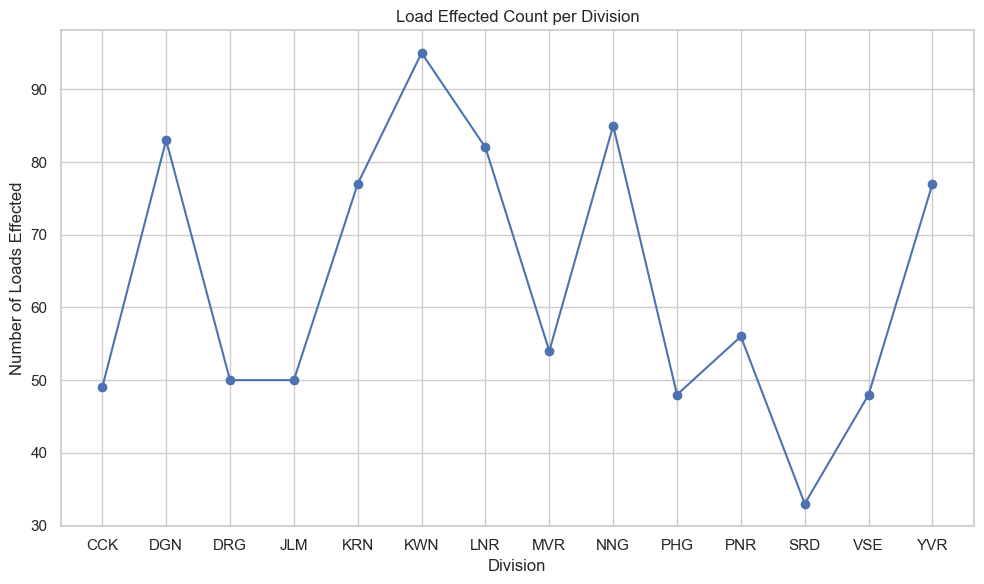

In [96]:
plt.figure(figsize=(10, 6))
plt.plot(division_per_Load_effect['DIVISION'], division_per_Load_effect['Load_Count'], marker='o', linestyle='-')
plt.title('Load Effected Count per Division')
plt.xlabel('Division')
plt.ylabel('Number of Loads Effected')
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

In [97]:
load_sum_per_division = df.groupby('DIVISION')['LOAD_EFFECTED'].sum().reset_index(name='Total_LOAD_EFFECTED')
load_sum_per_division

,DIVISION,Total_LOAD_EFFECTED
0,CCK,3772
1,DGN,14729
2,DRG,5207
3,JLM,7509
4,KRN,12095
5,KWN,18530
6,LNR,15381
7,MVR,6206
8,NNG,13001
9,PHG,5918


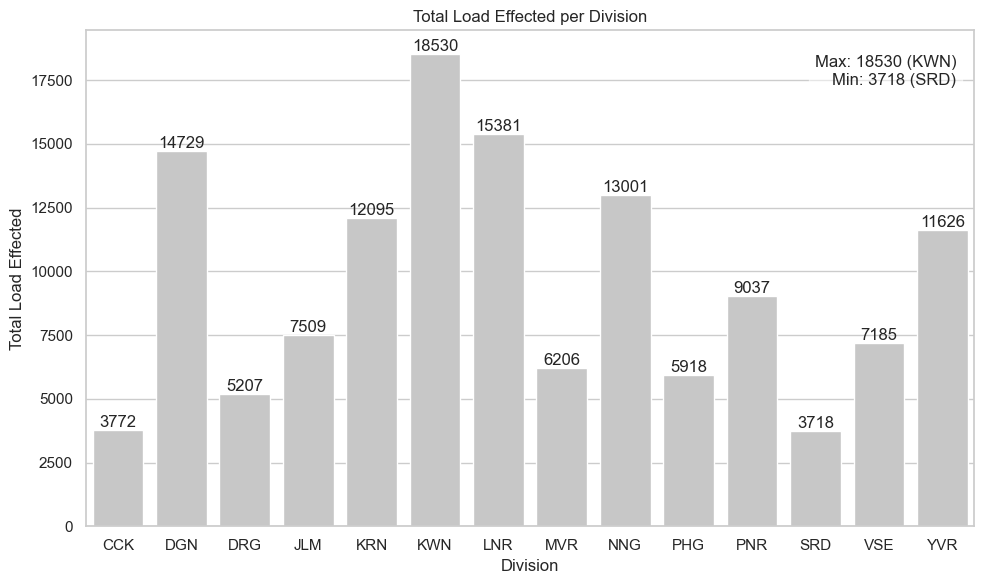

In [98]:
plt.figure(figsize=(10, 6))
zx = sns.barplot(x='DIVISION',y='Total_LOAD_EFFECTED', data=load_sum_per_division,color='#c7c7c7')
plt.title('Total Load Effected per Division')
plt.xlabel('Division')
plt.ylabel('Total Load Effected')
plt.xticks(rotation=0)
plt.tight_layout()
for container in zx.containers:
    zx.bar_label(container, label_type='edge')
max_row = load_sum_per_division.loc[load_sum_per_division['Total_LOAD_EFFECTED'].idxmax()]
min_row = load_sum_per_division.loc[load_sum_per_division['Total_LOAD_EFFECTED'].idxmin()]
max_count, max_division = max_row['Total_LOAD_EFFECTED'], max_row['DIVISION']
min_count, min_division = min_row['Total_LOAD_EFFECTED'], min_row['DIVISION']
annotation = (f'Max: {max_count} ({max_division})\n'
              f'Min: {min_count} ({min_division})')

plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))
plt.show()

In [99]:
entryMode_per_division = df.groupby(['DIVISION', 'ENTRY_MODE']).size().unstack(fill_value=0)[['AUTO TRIP', 'MANUAL','PARTIAL']]
entryMode_per_division

ENTRY_MODE,AUTO TRIP,MANUAL,PARTIAL
DIVISION,,,
CCK,117,48,0
DGN,236,106,0
DRG,134,32,2
JLM,144,84,0
KRN,175,110,22
KWN,248,91,0
LNR,297,168,1
MVR,145,83,0
NNG,215,78,0


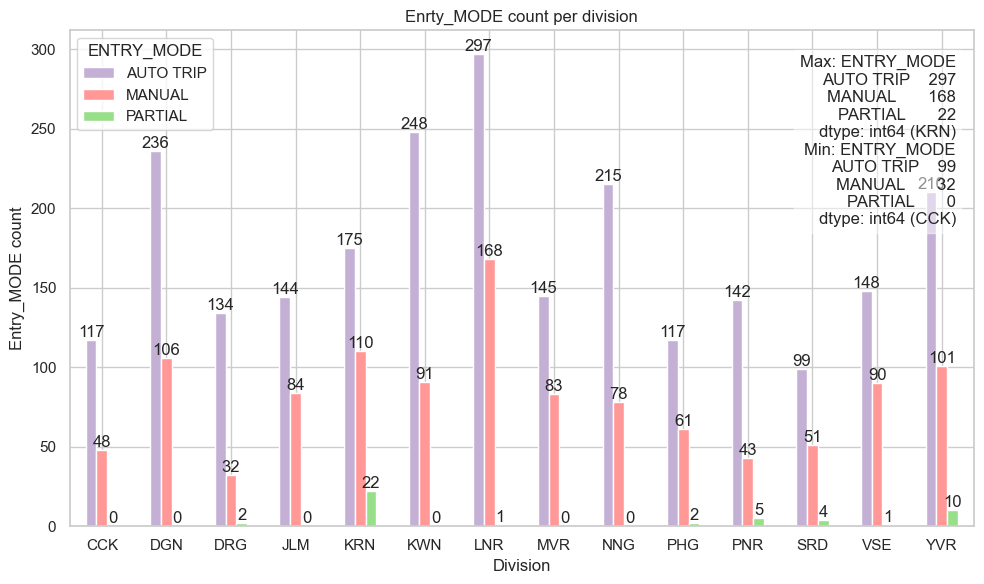

In [100]:
ax=entryMode_per_division.plot(kind='bar', figsize=(10, 6), color=['#c5b0d5','#ff9896','#98df8a'])
plt.title('Enrty_MODE count per division')
plt.xlabel('Division')
plt.ylabel('Entry_MODE count')
plt.xticks(rotation=0)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
max_count = entryMode_per_division.max()
min_count = entryMode_per_division.min()
max_division = entryMode_per_division[entryMode_per_division == max_count].stack().index[0][0]
min_division = entryMode_per_division[entryMode_per_division == min_count].stack().index[0][0]
annotation = (f'Max: {max_count} ({max_division})\n'
              f'Min: {min_count} ({min_division})')

plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))
plt.show()

In [101]:
df['INSERTEDDATE'] = pd.to_datetime(df['INSERTEDDATE'], errors='coerce')
df['CLOSINGDATE'] = pd.to_datetime(df['CLOSINGDATE'], errors='coerce')

In [102]:
df['Duration']= (df['CLOSINGDATE'] - df['INSERTEDDATE']).dt.total_seconds() / 3600

In [103]:
df[['INSERTEDDATE', 'CLOSINGDATE','Duration']].head()

,INSERTEDDATE,CLOSINGDATE,Duration
0,2024-04-09 14:05:59,2024-04-10 21:28:40,31.378056
1,2024-01-06 10:00:09,2024-01-06 10:25:56,0.429722
2,2024-01-08 14:17:09,2024-01-10 21:32:16,55.251944
3,2024-01-10 15:08:29,2024-01-11 22:33:13,31.412222
4,2024-01-23 10:53:13,2024-01-23 11:26:10,0.549167


In [104]:
df['Closed_within_1hr'] = df['Duration'] <= 1
print(df['Closed_within_1hr'].value_counts())

Closed_within_1hr
False    1955
True     1665
Name: count, dtype: int64


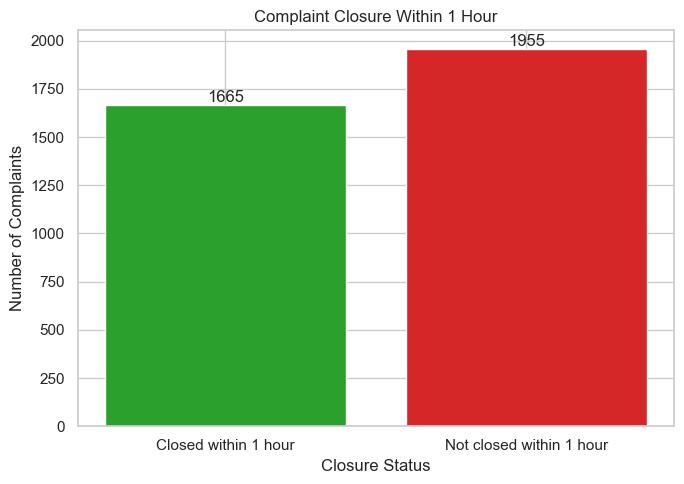

In [105]:
closed_counts = df['Closed_within_1hr'].value_counts().reindex([True, False], fill_value=0)
closed_counts.index = ['Closed within 1 hour', 'Not closed within 1 hour']
plt.figure(figsize=(7, 5))
bars = plt.bar(closed_counts.index, closed_counts.values, color=['#2ca02c', '#d62728'])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, int(height),
             ha='center', va='bottom', fontsize=12)

plt.title('Complaint Closure Within 1 Hour')
plt.xlabel('Closure Status')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

In [106]:
result = df.groupby(['DIVISION', 'Closed_within_1hr']).size().unstack(fill_value=0).reindex(columns=[True, False], fill_value=0)
result

Closed_within_1hr,True,False
DIVISION,,
CCK,82,83
DGN,151,191
DRG,57,111
JLM,116,112
KRN,166,141
KWN,149,190
LNR,215,251
MVR,109,119
NNG,151,142


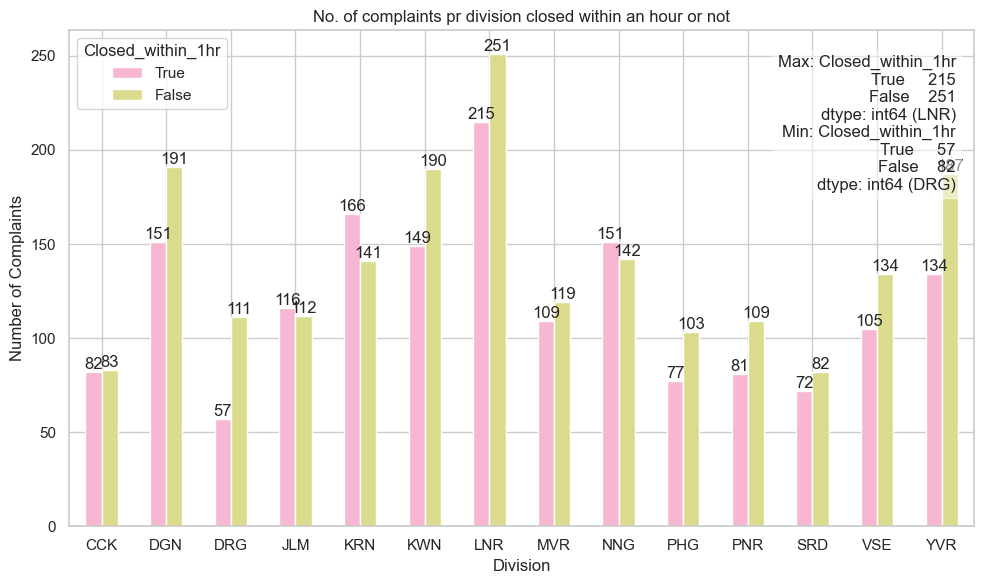

In [107]:
ax=result.plot(kind='bar', figsize=(10, 6), color=['#f7b6d2','#dbdb8d'])
plt.title('No. of complaints pr division closed within an hour or not')
plt.xlabel('Division')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=0)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
max_count = result.max()
min_count = result.min()
max_division = result[result == max_count].stack().index[0][0]
min_division = result[result == min_count].stack().index[0][0]
annotation = (f'Max: {max_count} ({max_division})\n'
              f'Min: {min_count} ({min_division})')

plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))
plt.show()

In [108]:
FaultLocation_counts = df['FAULTLOCATION'].value_counts()
print(FaultLocation_counts)

FAULTLOCATION
FEEDER        2320
LTFEEDER      1157
SUBSTATION      72
DT              71
Name: count, dtype: int64


In [109]:
total_counts = df['FAULTLOCATION'].value_counts().reindex(['FEEDER', 'LTFEEDER','SUBSTATION','DT'], fill_value=0)

Text(0.98, 0.95, 'Max: 2320 (FEEDER)\nMin: 71 (DT)')

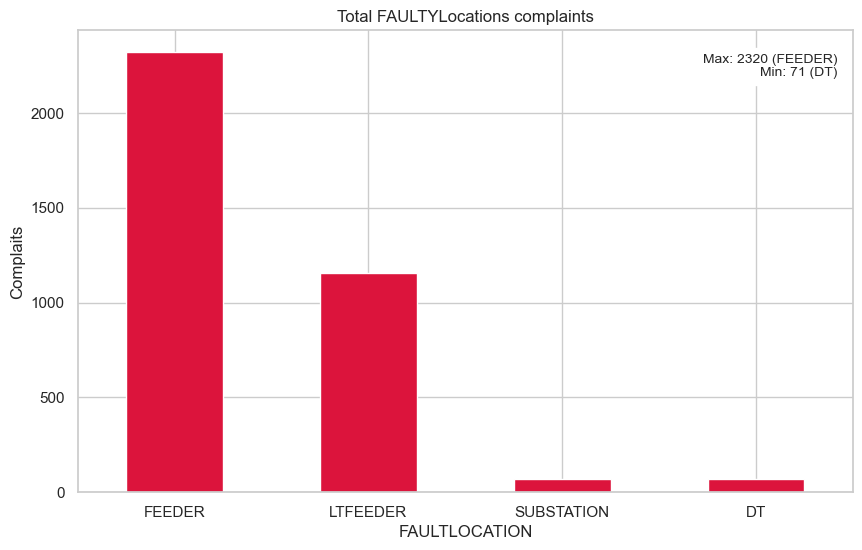

In [110]:
total_counts.plot(kind='bar',figsize=(10,6),color ='crimson')
plt.title('Total FAULTYLocations complaints')
plt.ylabel('Complaits')
plt.xticks(rotation=0)
max_count= total_counts.max()
min_count = total_counts.min()
max_category = total_counts.idxmax()
min_category = total_counts.idxmin()
annotation = f"Max: {max_count} ({max_category})\nMin: {min_count} ({min_category})"
plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=10,
               bbox=dict(facecolor='white'))

In [111]:
FaultLocation_counts = df['RELAY_REASON'].value_counts()
print(FaultLocation_counts)

RELAY_REASON
TRIPPING          3004
LOAD REDUCED       348
LOAD DISAPPEAR     214
Name: count, dtype: int64


In [112]:
total_counts = df['RELAY_REASON'].value_counts().reindex(['TRIPPING', 'LOAD REDUCED','LOAD DISAPPEAR'], fill_value=0)

Text(0.98, 0.95, 'Max: 3004 (TRIPPING)\nMin: 214 (LOAD DISAPPEAR)')

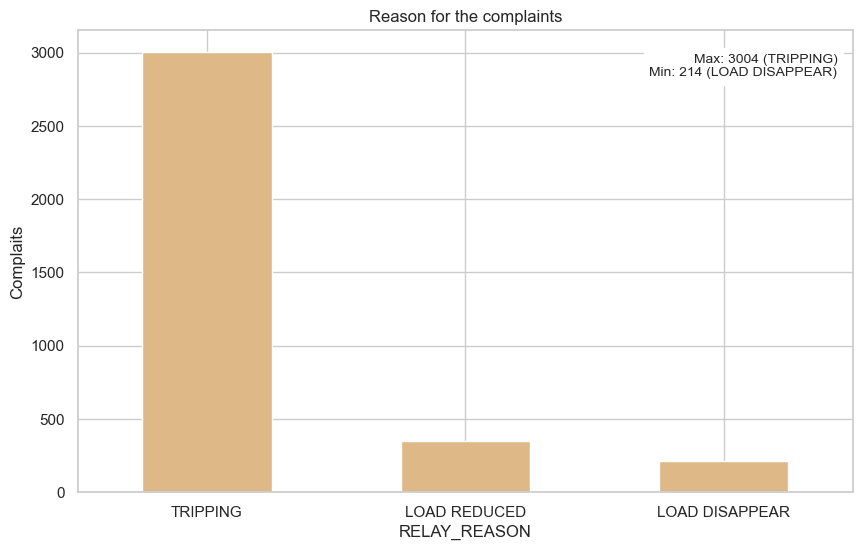

In [113]:
total_counts.plot(kind='bar',figsize=(10,6),color ='burlywood')
plt.title('Reason for the complaints')
plt.ylabel('Complaits')
plt.xticks(rotation=0)
max_count= total_counts.max()
min_count = total_counts.min()
max_category = total_counts.idxmax()
min_category = total_counts.idxmin()
annotation = f"Max: {max_count} ({max_category})\nMin: {min_count} ({min_category})"
plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=10,
               bbox=dict(facecolor='white'))

In [114]:
Fault_Reason = df.groupby(['FAULTLOCATION', 'RELAY_REASON']).size().unstack(fill_value=0)[['TRIPPING', 'LOAD REDUCED','LOAD DISAPPEAR']]
Fault_Reason

RELAY_REASON,TRIPPING,LOAD REDUCED,LOAD DISAPPEAR
FAULTLOCATION,,,
DT,69,0,2
FEEDER,2217,61,27
LTFEEDER,646,287,185
SUBSTATION,72,0,0


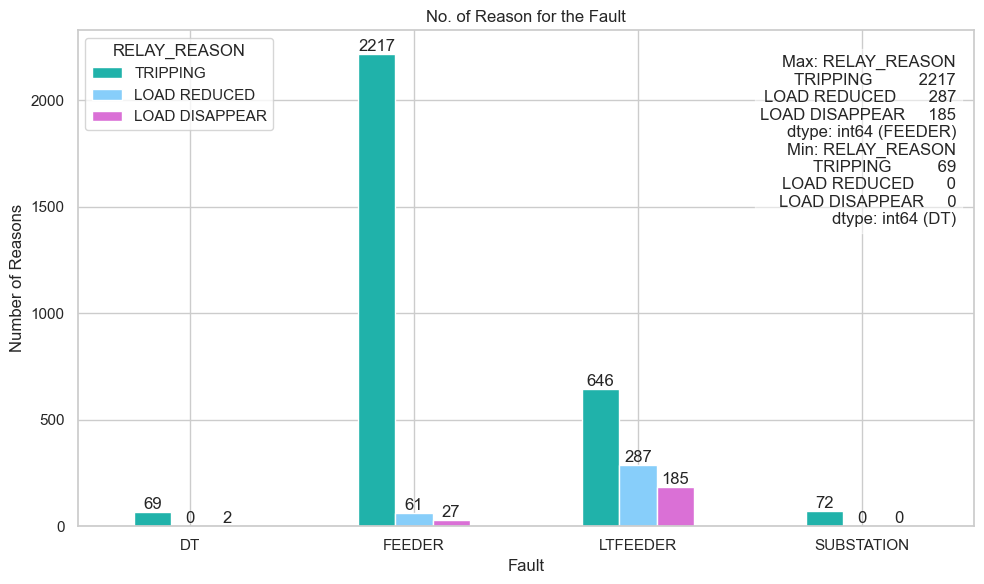

In [115]:
ax=Fault_Reason.plot(kind='bar', figsize=(10, 6), color=['lightseagreen','lightskyblue','orchid'])
plt.title('No. of Reason for the Fault')
plt.xlabel('Fault')
plt.ylabel('Number of Reasons')
plt.xticks(rotation=0)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
max_count = Fault_Reason.max()
min_count = Fault_Reason.min()
max_division = Fault_Reason[Fault_Reason == max_count].stack().index[0][0]
min_division = Fault_Reason[Fault_Reason == min_count].stack().index[0][0]
annotation = (f'Max: {max_count} ({max_division})\n'
              f'Min: {min_count} ({min_division})')

plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))
plt.show()

In [116]:
_counts = df['BACK_FEEDING'].value_counts()
print(_counts)

BACK_FEEDING
1    1956
0    1664
Name: count, dtype: int64


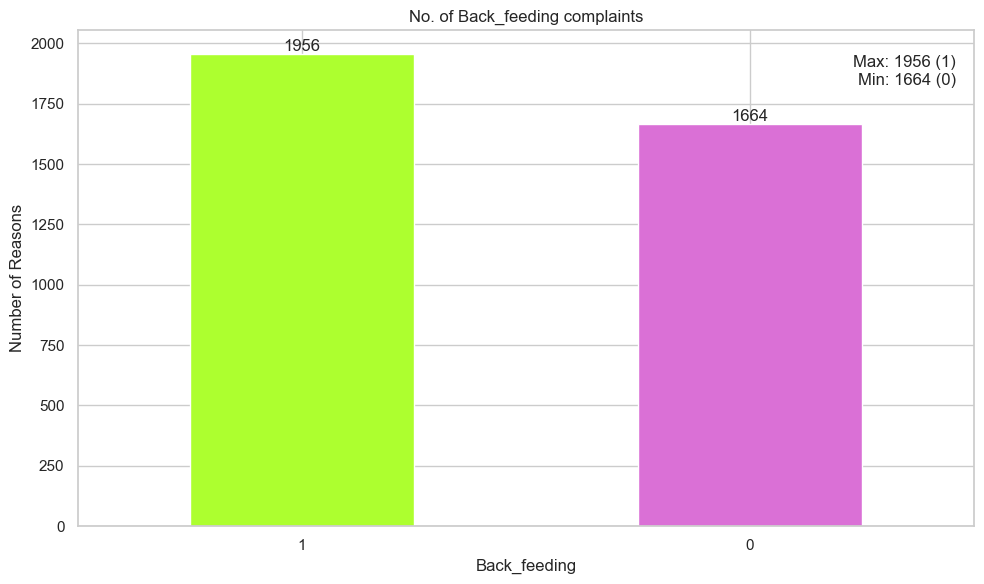

In [117]:
ax=_counts.plot(kind='bar', figsize=(10, 6), color=['greenyellow','orchid'])
plt.title('No. of Back_feeding complaints')
plt.xlabel('Back_feeding')
plt.ylabel('Number of Reasons')
plt.xticks(rotation=0)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
max_count = _counts.max()
min_count = _counts.min()
max_division = _counts.idxmax()
min_division = _counts.idxmin()
annotation = (f'Max: {max_count} ({max_division})\n'
              f'Min: {min_count} ({min_division})')

plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))
plt.show()

In [118]:
_counts = df['IRP_STATUS'].fillna('Not Done').value_counts()
print(_counts)


IRP_STATUS
Not Done    2120
IRP DONE    1500
Name: count, dtype: int64


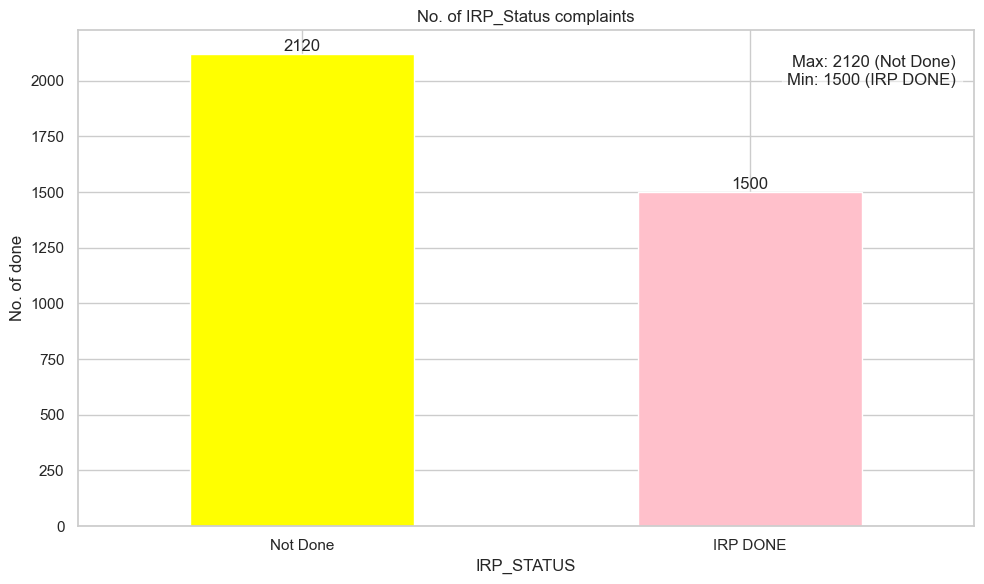

In [119]:
ax=_counts.plot(kind='bar', figsize=(10, 6), color=['yellow','pink'])
plt.title('No. of IRP_Status complaints')
plt.xlabel('IRP_STATUS')
plt.ylabel('No. of done')
plt.xticks(rotation=0)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
max_count = _counts.max()
min_count = _counts.min()
max_division = _counts.idxmax()
min_division = _counts.idxmin()
annotation = (f'Max: {max_count} ({max_division})\n'
              f'Min: {min_count} ({min_division})')

plt.gca().text(0.98, 0.95, annotation,
               ha='right', va='top',
               transform=plt.gca().transAxes,
               fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))
plt.show()

In [120]:
No_of_complaints = df['ASSOCIATED_FAULT'].nunique()
No_of_complaints

1744

In [121]:
complaints_per_divison = df.groupby(['DIVISION'])['ASSOCIATED_FAULT'].nunique().reset_index(name='ASSfault_Count')
complaints_per_divison

,DIVISION,ASSfault_Count
0,CCK,64
1,DGN,155
2,DRG,80
3,JLM,119
4,KRN,171
5,KWN,146
6,LNR,239
7,MVR,109
8,NNG,133
9,PHG,91


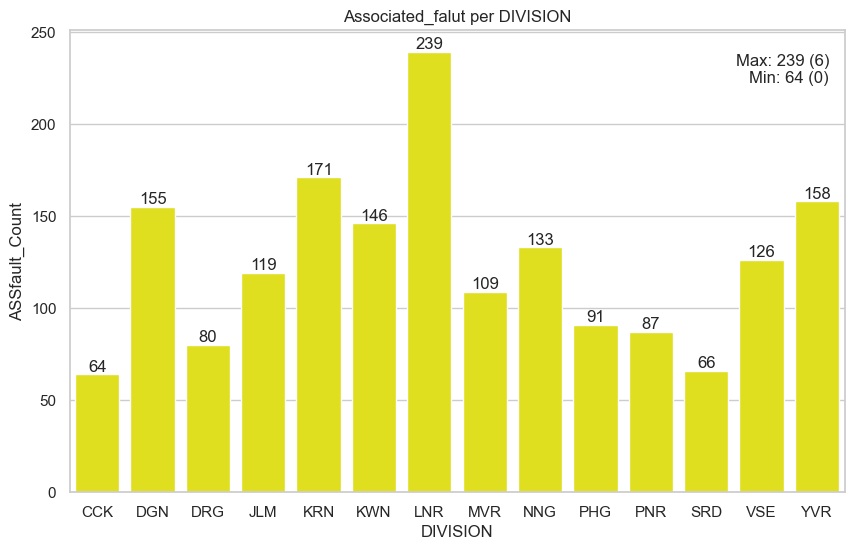

In [122]:
plt.figure(figsize=(10, 6))
ax=sns.barplot(x='DIVISION', y='ASSfault_Count', data=complaints_per_divison,color = 'yellow')
plt.title("Associated_falut per DIVISION")
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
max_val = complaints_per_divison['ASSfault_Count'].max()
min_val = complaints_per_divison['ASSfault_Count'].min()
max_division = complaints_per_divison[complaints_per_divison == max_val].stack().index[0][0]
min_division = complaints_per_divison[complaints_per_divison == min_val].stack().index[0][0]

annotation = (f'Max: {max_val} ({max_division})\n'
              f'Min: {min_val} ({min_division})')

plt.gca().text(0.98, 0.95, annotation, ha='right', va='top',
               transform=plt.gca().transAxes, fontsize=12,
               bbox=dict(facecolor='white', alpha=0.5))

plt.show()
